# Menghitung CSAT Score tiap cabang Tomoro Coffee di Samarinda

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
df = pd.read_parquet('data_review_full_bersih.parquet')
df.head()

,nama_reviewer,rating,waktu_relatif,review,Makanan,Layanan,Suasana,Tarif per orang,Tingkat kebisingan,Waktu tunggu,Jenis pesanan,Jenis makanan,Tempat parkir,Opsi tempat parkir,Ukuran grup,cafe,Tingkat Kepuasan,tanggal_pasti
0,Rizak Mada Astanto,5,2 hari lalu,Terbaiiik,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PM Noor Samarinda,Puas,2026-06-24
1,Diah ADHYAKSANTI,5,1 minggu lalu,"Makanan enak, pelayanan bagus, dan kebisingan ...",<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PM Noor Samarinda,Puas,2026-06-19
2,Sonia Ramadhani,1,1 minggu lalu,"Hapus aja sistem poing member di app, percuma ...",4,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PM Noor Samarinda,Tidak Puas,2026-06-19
3,Muhammad Yos Christian,4,1 bulan lalu,None,5,5,4,Rp 25–50 rb,"Tenang, mudah untuk bicara",Tidak menunggu,NaN,NaN,NaN,NaN,NaN,PM Noor Samarinda,Puas,2026-05-26
4,Ainur aja,5,1 bulan lalu,None,<NA>,5,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PM Noor Samarinda,Puas,2026-05-26


### Overall Rating All Tomoro Coffee samarinda

In [4]:
df['Tingkat Kepuasan'].isnull().sum()

0

In [5]:
df['Tingkat Kepuasan'].shape

(1558,)

In [6]:
df['Tingkat Kepuasan'].unique()

['Puas', 'Tidak Puas', 'Netral']
Categories (3, object): ['Tidak Puas' < 'Netral' < 'Puas']

In [7]:
#persentase tiap kategori
print(f'{round(df['Tingkat Kepuasan'].value_counts(normalize=True) * 100, 2).sort_index()}')

Tingkat Kepuasan
Tidak Puas     6.55
Netral         2.44
Puas          91.01
Name: proportion, dtype: float64


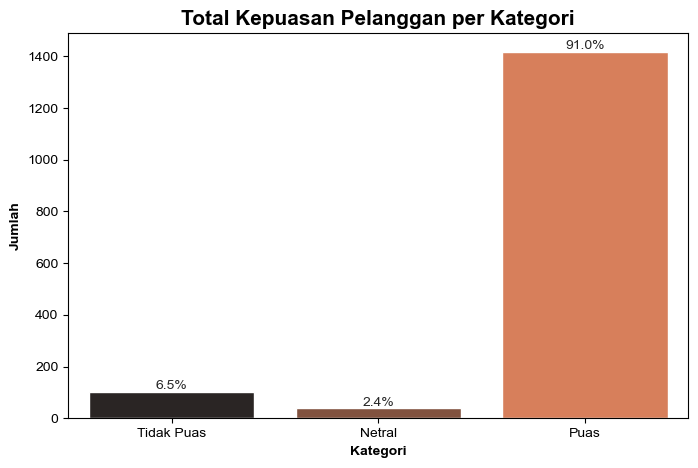

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8,5))

sns.set_style("white")

ax = sns.countplot(data=df, x='Tingkat Kepuasan', hue='Tingkat Kepuasan', palette='dark:#ec7646')

plt.title("Total Kepuasan Pelanggan per Kategori", fontsize=15, fontweight='bold')
plt.ylabel("Jumlah", fontweight='bold')
plt.xlabel("Kategori", fontweight='bold')

total_data = len(df)

for container in ax.containers:
    labels = []
    for v in container:
        count = int(v.get_height())
        percentage = (count / total_data) * 100
        labels.append(f'{percentage:.1f}%')
    
    ax.bar_label(container, labels=labels)

plt.savefig(
    'data_viz/Kepuasan_Pelanggan_per_Kategori.png', 
    dpi=300, 
    bbox_inches='tight'
)

plt.show()

### CSAT setiap cabang Tomoro Coffee Samarinda

### Rumus CSAT:
### $$CSAT = \left( \frac{\text{Jumlah Review Bintang 4 dan 5}}{\text{Total Seluruh Review (Bintang 1 sampai 5)}} \right) \times 100\%$$

In [11]:
#total puas
puas_filt = df['Tingkat Kepuasan'] == 'Puas'
total_puas = df.loc[puas_filt].shape[0]
total_puas

1418

In [12]:
#total semua
total_semua = df['Tingkat Kepuasan'].shape[0]
total_semua

1558

In [13]:
#CSAT Score seluruh cabang Samarinda 
hasil_csat_all = round((total_puas / total_semua) * 100,2)
print(f"Hasil CSAT Seluruh Cabang Tomoro Coffee Samarinda: {hasil_csat_all}%")

Hasil CSAT Seluruh Cabang Tomoro Coffee Samarinda: 91.01%


### Score CSAT berdasarkan cabang Tomoro Coffee di Samarinda

In [15]:
#list cabang
df['cafe'].unique()

['PM Noor Samarinda', 'M Yamin', 'Sebatik', 'Merak Square', 'Bung Tomo']
Categories (5, object): ['PM Noor Samarinda' < 'M Yamin' < 'Sebatik' < 'Merak Square' < 'Bung Tomo']

#### M Yamin

In [17]:
#filter berdasarkan cafe pertama: M Yamin
filt_yamin = df['cafe']=='M Yamin'
total_yamin = df.loc[filt_yamin]
df.loc[filt_yamin].head(2)

,nama_reviewer,rating,waktu_relatif,review,Makanan,Layanan,Suasana,Tarif per orang,Tingkat kebisingan,Waktu tunggu,Jenis pesanan,Jenis makanan,Tempat parkir,Opsi tempat parkir,Ukuran grup,cafe,Tingkat Kepuasan,tanggal_pasti
234,Risky Narran,5,5 hari lalu,None,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M Yamin,Puas,2026-06-21
235,Nadia Pradita,1,1 minggu lalu,ihhh sekarang minta rate bintang 5 ke customer...,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M Yamin,Tidak Puas,2026-06-19


In [18]:
# filter berdasarkan puas dan cafe myamin
filt_puas = df['Tingkat Kepuasan'] == 'Puas'
total_yamin_puas = df.loc[filt_yamin & filt_puas]
df.loc[filt_yamin & filt_puas].head(2)

,nama_reviewer,rating,waktu_relatif,review,Makanan,Layanan,Suasana,Tarif per orang,Tingkat kebisingan,Waktu tunggu,Jenis pesanan,Jenis makanan,Tempat parkir,Opsi tempat parkir,Ukuran grup,cafe,Tingkat Kepuasan,tanggal_pasti
234,Risky Narran,5,5 hari lalu,None,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M Yamin,Puas,2026-06-21
238,Raha Dian,5,1 minggu lalu,Dapat promo buy 1 get 1 👍,5,5,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M Yamin,Puas,2026-06-19


In [19]:
#hitung CSAT
yamin = (total_yamin_puas.shape[0] / total_yamin.shape[0]) * 100
print(f'Total CSAT Tomoro Coffee Cabang M Yamin: {round(yamin, 2)}%')

Total CSAT Tomoro Coffee Cabang M Yamin: 86.84%


### Automatisasi

In [21]:
list(df['cafe'].unique())

['PM Noor Samarinda', 'M Yamin', 'Sebatik', 'Merak Square', 'Bung Tomo']

In [22]:
#dict for visualization
cafe_viz = {}

for i in list(df['cafe'].unique()):
    #filter berdasarkan cafe pertama: M Yamin
    filt_cafe = df['cafe']== i
    total_cafe = df.loc[filt_cafe]
    # filter berdasarkan puas dan cafe myamin
    filt_puas = df['Tingkat Kepuasan'] == 'Puas'
    total_puas = df.loc[filt_cafe & filt_puas]
    #hitung CSAT
    cafe = (total_puas.shape[0] / total_cafe.shape[0]) * 100
    cafe_viz[i] =  round(cafe, 2)
    print(f'Total CSAT Tomoro Coffee Cabang {i}: {round(cafe, 2)}%')

Total CSAT Tomoro Coffee Cabang PM Noor Samarinda: 89.74%
Total CSAT Tomoro Coffee Cabang M Yamin: 86.84%
Total CSAT Tomoro Coffee Cabang Sebatik: 93.73%
Total CSAT Tomoro Coffee Cabang Merak Square: 91.49%
Total CSAT Tomoro Coffee Cabang Bung Tomo: 90.43%


In [23]:
df_csat = pd.DataFrame(cafe_viz.items(), columns=['Nama Cafe', 'CSAT (%)'])

In [24]:
df_csat

,Nama Cafe,CSAT (%)
0,PM Noor Samarinda,89.74
1,M Yamin,86.84
2,Sebatik,93.73
3,Merak Square,91.49
4,Bung Tomo,90.43


In [25]:
#shorting dari trendah ke tertinggi
df_csat_1 = df_csat.sort_values(by='CSAT (%)', ascending=True)

In [26]:
df_csat_1

,Nama Cafe,CSAT (%)
1,M Yamin,86.84
0,PM Noor Samarinda,89.74
4,Bung Tomo,90.43
3,Merak Square,91.49
2,Sebatik,93.73


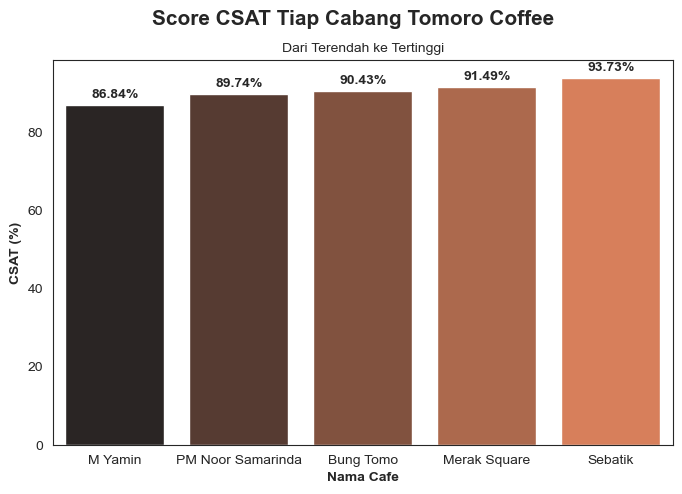

In [27]:
## data viz
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=df_csat_1['Nama Cafe'], y=df_csat_1['CSAT (%)'], hue=df_csat_1['Nama Cafe'], palette='dark:#ec7646')
plt.suptitle("Score CSAT Tiap Cabang Tomoro Coffee", fontsize=15, fontweight='bold')
plt.title("Dari Terendah ke Tertinggi", fontsize=10)
plt.xlabel('Nama Cafe',fontweight='bold')
plt.ylabel('CSAT (%)',fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontweight='bold')

plt.savefig(
    'data_viz/Score_CSAT_Tiap_Cabang_Tomoro_Coffee.png', 
    dpi=300, 
    bbox_inches='tight'
)

plt.show()

### Rata-rata rating berdasarkan perhitungan Google Maps

In [29]:
df2 = pd.read_parquet('data_bisnis_full_bersih.parquet')
df2

,nama,alamat,nomor_hp,instagram,bintang,total_ulasan,Kecamatan
0,TOMORO COFFEE - PM NOOR SAMARINDA,"Jl. PM. Noor, Sempaja Sel., Kec. Samarinda Uta...",None,None,4.6,234,Samarinda Utara
1,TOMORO COFFEE - M YAMIN,"l. M. Yamin No.8, Gn. Kelua, Kec. Samarinda Ul...",858-3311-6666,None,4.5,190,Samarinda Ulu
2,TOMORO COFFEE - SEBATIK SAMARINDA,"F5X2+FWW, Jl. Pulau Sebatik, Pelabuhan, Kec. S...",0822-8111-2323,https://www.instagram.com/tommunitysebatik,4.7,335,Samarinda Kota
3,TOMORO COFFEE - MERAK SQUARE SAMARINDA,"Komplek Merak Square, Jl. Hasan Basri No. 53, ...",0822-8111-2323,https://www.instagram.com/tommunitymeraksquare...,4.7,611,Sungai Pinang
4,TOMORO COFFEE - BUNG TOMO,"Jl. Bung Tomo No.68e, Sungai Keledang, Kec. Sa...",None,None,4.6,188,Samarinda Seberang


In [30]:
#Copy dan membuang kolom yang tidak dibutuhkan
dfc = df2.copy()
dfc = dfc.drop(columns=['alamat', 'nomor_hp', 'instagram', 'total_ulasan', 'Kecamatan'])
#mempersingkat nama untuk viz
pattern = r'^TOMORO COFFEE - | SAMARINDA$'
dfc['nama'] = dfc['nama'].str.replace(pattern, '', regex=True).str.strip()

In [31]:
#sorting terendah ke tertinggi
dfc = dfc.sort_values(by='bintang')
dfc

,nama,bintang
1,M YAMIN,4.5
0,PM NOOR,4.6
4,BUNG TOMO,4.6
2,SEBATIK,4.7
3,MERAK SQUARE,4.7


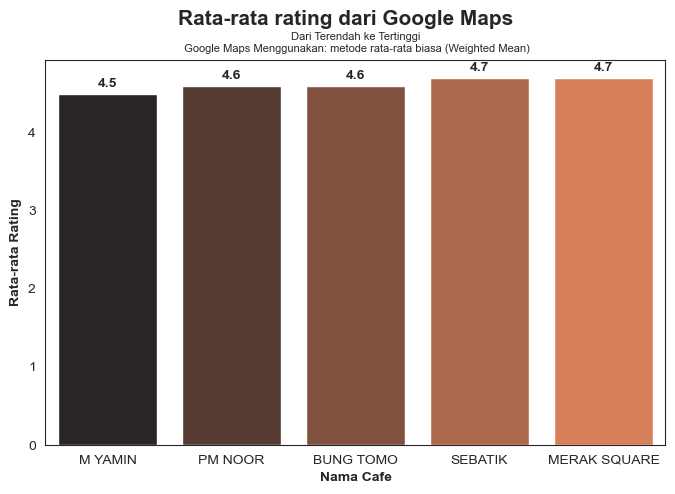

In [32]:
#data viz
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=dfc['nama'], y=dfc['bintang'], hue=dfc['nama'], palette='dark:#ec7646')
plt.suptitle("Rata-rata rating dari Google Maps", fontsize=15, fontweight='bold')

notes="Dari Terendah ke Tertinggi\n Google Maps Menggunakan: metode rata-rata biasa (Weighted Mean)"

plt.title(notes, fontsize=8)

plt.xlabel('Nama Cafe',fontweight='bold')
plt.ylabel('Rata-rata Rating',fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold')

plt.savefig(
    'data_viz/Rata-rata_rating_dari_Google_Maps.png', 
    dpi=300, 
    bbox_inches='tight'
)

plt.show()

In [33]:
#validated the result with the rating inside individual review.
for i in list(df.cafe.unique()):
    filt = df['cafe'] == i
    cafe = df.loc[filt]
    result = cafe['rating'].mean()
    print(f'cafe: {i} and mean: {round(result,1)}')

cafe: PM Noor Samarinda and mean: 4.6
cafe: M Yamin and mean: 4.5
cafe: Sebatik and mean: 4.7
cafe: Merak Square and mean: 4.7
cafe: Bung Tomo and mean: 4.6


### Kuadran Analisi Performa tiap cabang

In [35]:
#mengamgil data yang dibutuhkan untuk analisa kuadran
kuadran_data = df_csat_1.copy()
kuadran_data['total_ulasan'] = df2['total_ulasan']
kuadran_data

,Nama Cafe,CSAT (%),total_ulasan
1,M Yamin,86.84,190
0,PM Noor Samarinda,89.74,234
4,Bung Tomo,90.43,188
3,Merak Square,91.49,611
2,Sebatik,93.73,335


In [36]:
#menentukan komparasi kuadran tengah dengan nilai rata-rata
#ini bisa di adjust sesuai dengan kpi perusahaan 
#rata-rata digunakan sebagai standard universal karena kpi internal perusahaan tidak diketahui untuk tiap cabang
#mean digunakan untuk csat karena perbedaan tidak terlalu jauh dan tidak ada outlier
#median digunakan untuk total_ulasan karena ada outlier dan ketika ada outlier median menjadi yang paling cocok
csat_mid = kuadran_data['CSAT (%)'].mean()
total_ulasan_mid = kuadran_data['total_ulasan'].median()

In [37]:
kuadran_data['total_ulasan'].std()

177.67470275759575

In [38]:
kuadran_data['CSAT (%)'].std()

2.518755645154964

In [39]:
total_ulasan_mid

234.0

In [40]:
csat_mid

90.446

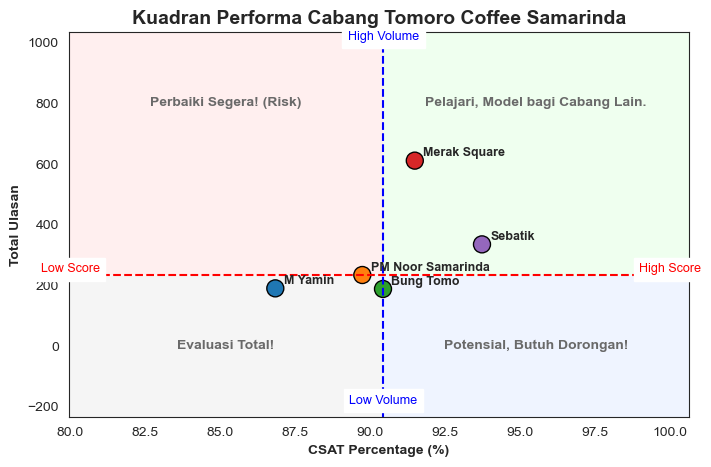

In [41]:
#data viz
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=kuadran_data, x='CSAT (%)', y='total_ulasan', hue='Nama Cafe', s=150, edgecolor='black', legend=False)
plt.axhline(y=total_ulasan_mid, color="red", linestyle="--", linewidth=1.5)
plt.axvline(x=csat_mid, color="blue", linestyle="--", linewidth=1.5)
ax.margins(x=1, y=1)
for _, row in kuadran_data.iterrows():
    ax.annotate(
        row['Nama Cafe'],
        (row['CSAT (%)'], row['total_ulasan']),
        textcoords="offset points",
        xytext=(6,3),    
        fontsize=9,
        fontweight='bold'
    )
plt.title("Kuadran Performa Cabang Tomoro Coffee Samarinda", fontsize=14, fontweight='bold')
plt.xlabel("CSAT Percentage (%)", fontweight='bold')
plt.ylabel("Total Ulasan", fontweight='bold')

#label for high and low volume of review
ax.text(
    csat_mid,-200,   
    "Low Volume",           
    fontsize=9,
    color='blue',
    ha='center', va='bottom',     
    backgroundcolor='white'     
)
ax.text(
    csat_mid, 1000,   
    "High Volume",           
    fontsize=9,
    color='blue',
    ha='center', va='bottom',     
    backgroundcolor='white'     
)

#label for high and low volume of score
ax.text(
    100, total_ulasan_mid,   
    "High Score",           
    fontsize=9,
    color='red',
    ha='center', va='bottom',     
    backgroundcolor='white'     
)
ax.text(
    80, total_ulasan_mid,   
    "Low Score",           
    fontsize=9,
    color='red',
    ha='center', va='bottom',     
    backgroundcolor='white'     
)


##warnain tiap garis
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
# Kuadran kiri-atas (Low Score, High Volume)
ax.add_patch(patches.Rectangle(
    (xmin, total_ulasan_mid), csat_mid - xmin, ymax - total_ulasan_mid,
    facecolor='#ffcccc', alpha=0.3, zorder=0
))
# Kuadran kanan-atas (High Score, High Volume) 
ax.add_patch(patches.Rectangle(
    (csat_mid, total_ulasan_mid), xmax - csat_mid, ymax - total_ulasan_mid,
    facecolor='#ccffcc', alpha=0.3, zorder=0
))
# Kuadran kiri-bawah (Low Score, Low Volume)
ax.add_patch(patches.Rectangle(
    (xmin, ymin), csat_mid - xmin, total_ulasan_mid - ymin,
    facecolor='#e0e0e0', alpha=0.3, zorder=0
))
# Kuadran kanan-bawah (High Score, Low Volume)
ax.add_patch(patches.Rectangle(
    (csat_mid, ymin), xmax - csat_mid, total_ulasan_mid - ymin,
    facecolor='#ccddff', alpha=0.3, zorder=0
))
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)


##text for context
# Titik tengah tiap kuadran
x_left_mid = (xmin + csat_mid) / 2
x_right_mid = (csat_mid + xmax) / 2
y_top_mid = 800
y_bottom_mid = (ymin + total_ulasan_mid) / 2

# Kiri-atas
ax.text(x_left_mid, y_top_mid, 'Perbaiki Segera! (Risk)',
        fontsize=10, fontweight='bold', color='dimgray',
        ha='center', va='center', zorder=1)

# Kanan-atas
ax.text(x_right_mid, y_top_mid, 'Pelajari, Model bagi Cabang Lain.',
        fontsize=10, fontweight='bold', color='dimgray',
        ha='center', va='center', zorder=1)

# Kiri-bawah
ax.text(x_left_mid, y_bottom_mid, 'Evaluasi Total!',
        fontsize=10, fontweight='bold', color='dimgray',
        ha='center', va='center', zorder=1)

# Kanan-bawah
ax.text(x_right_mid, y_bottom_mid, 'Potensial, Butuh Dorongan!',
        fontsize=10, fontweight='bold', color='dimgray',
        ha='center', va='center', zorder=1)

plt.savefig(
    'data_viz/Kuadran_Performa_Cabang_Tomoro_Coffee_Samarinda.png', 
    dpi=300, 
    bbox_inches='tight'
)

plt.show()

# Trend CSAT dalam 2 tahun belakang (CSAT overtime by score 0-100%)

In [7]:
df = pd.read_parquet('data_review_full_bersih.parquet')
df.head(3)

,nama_reviewer,rating,waktu_relatif,review,Makanan,Layanan,Suasana,Tarif per orang,Tingkat kebisingan,Waktu tunggu,Jenis pesanan,Jenis makanan,Tempat parkir,Opsi tempat parkir,Ukuran grup,cafe,Tingkat Kepuasan,tanggal_pasti
0,Rizak Mada Astanto,5,2 hari lalu,Terbaiiik,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PM Noor Samarinda,Puas,2026-06-24
1,Diah ADHYAKSANTI,5,1 minggu lalu,"Makanan enak, pelayanan bagus, dan kebisingan ...",<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PM Noor Samarinda,Puas,2026-06-19
2,Sonia Ramadhani,1,1 minggu lalu,"Hapus aja sistem poing member di app, percuma ...",4,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PM Noor Samarinda,Tidak Puas,2026-06-19


In [9]:
# menyatukan skor csat berdasarkan waktu_relatif di plot dan menggunakan tahun-bulan average csat
df['waktu_relatif'].unique()

array(['2 hari lalu', '1 minggu lalu', '1 bulan lalu', '2 bulan lalu',
       '3 bulan lalu', '4 bulan lalu', '5 bulan lalu', '6 bulan lalu',
       '7 bulan lalu', '8 bulan lalu', '9 bulan lalu', '10 bulan lalu',
       '11 bulan lalu', '1 tahun lalu', '5 hari lalu', '2 minggu lalu',
       '3 minggu lalu', '4 minggu lalu', '1 hari lalu', '4 hari lalu',
       '6 hari lalu'], dtype=object)

In [11]:
#mengabungkan berdasarkan waktu relatid dan menghitung skor CSAT semua cabang cafe
# list untuk menampung hasil looping
container_df = []
#data ynag dibutuhkan
cafe_data = df[["cafe", "waktu_relatif", "rating", "Tingkat Kepuasan"]].copy()

#looping semua daftar cafe
for nama_cafe in cafe_data["cafe"].unique():
    # Filter per cafe
    filt = cafe_data["cafe"] == nama_cafe
    #ambil data per cafe
    df_per_cafe = cafe_data.loc[filt]

    # Hitung CSAT
    df_csat = (
        #mengambil tingkat kepuasan dan grupby waktu_relatif
        df_per_cafe.groupby("waktu_relatif")["Tingkat Kepuasan"]
        #menghitung csat dengan total puas dibagi total kepuasan kali 100
        .apply(lambda x: (x.isin(["Puas"]).sum() / x.count()) * 100)
        #reset index
        .reset_index()
    )
    #mengubah nama tingkat kepuasan menjadi skor_csat
    df_csat = df_csat.rename(columns={"Tingkat Kepuasan": "skor_csat"})
    #menambahkan kolom cafe berdasarkan yang kita looping
    df_csat["cafe"] = nama_cafe

    #menambahkan total review yang dihitung 
    total_review_per_waktu = df_per_cafe.groupby("waktu_relatif")["Tingkat Kepuasan"].count()
    df_csat["total_review"] = df_csat["waktu_relatif"].map(total_review_per_waktu)
    #easukan df satu per satu ke container
    container_df.append(df_csat)

#concat seluruh container dan ignore index
df_akhir_csat = pd.concat(container_df, ignore_index=True)

df_akhir_csat

,waktu_relatif,skor_csat,cafe,total_review
0,1 bulan lalu,63.636364,PM Noor Samarinda,11
1,1 minggu lalu,50.000000,PM Noor Samarinda,2
2,1 tahun lalu,95.714286,PM Noor Samarinda,140
3,10 bulan lalu,100.000000,PM Noor Samarinda,9
4,11 bulan lalu,80.000000,PM Noor Samarinda,10
...,...,...,...,...
64,6 bulan lalu,90.000000,Bung Tomo,10
65,6 hari lalu,100.000000,Bung Tomo,1
66,7 bulan lalu,85.714286,Bung Tomo,14
67,8 bulan lalu,84.615385,Bung Tomo,13


In [13]:
df['waktu_relatif'].unique()

array(['2 hari lalu', '1 minggu lalu', '1 bulan lalu', '2 bulan lalu',
       '3 bulan lalu', '4 bulan lalu', '5 bulan lalu', '6 bulan lalu',
       '7 bulan lalu', '8 bulan lalu', '9 bulan lalu', '10 bulan lalu',
       '11 bulan lalu', '1 tahun lalu', '5 hari lalu', '2 minggu lalu',
       '3 minggu lalu', '4 minggu lalu', '1 hari lalu', '4 hari lalu',
       '6 hari lalu'], dtype=object)

In [15]:
#mengurutkan waktu untuk plot
urutan_waktu = [
    "1 tahun lalu",
    "11 bulan lalu",
    "10 bulan lalu",
    "9 bulan lalu",
    "8 bulan lalu",
    "7 bulan lalu",
    "6 bulan lalu",
    "5 bulan lalu",
    "4 bulan lalu",
    "3 bulan lalu",
    "2 bulan lalu",
    "1 bulan lalu",
    "4 minggu lalu",
    "3 minggu lalu",
    "2 minggu lalu",
    "1 minggu lalu",
    "6 hari lalu",
    "5 hari lalu",
    "4 hari lalu",
    "2 hari lalu",
    "1 hari lalu",
]

#mengubah kolom relatif menjadi data tipe categorical agar urutan waktunya sesuai
df_akhir_csat["waktu_relatif"] = pd.Categorical(
    df_akhir_csat["waktu_relatif"], categories=urutan_waktu, ordered=True
)

#sorting berdasarkan waktu relatif lalu cafe
df_akhir_csat = df_akhir_csat.sort_values(
    by=["waktu_relatif", "cafe"]
).reset_index(drop=True)

# Cek hasil akhir
df_akhir_csat.head(10)

,waktu_relatif,skor_csat,cafe,total_review
0,1 tahun lalu,90.429043,Merak Square,303
1,1 tahun lalu,95.714286,PM Noor Samarinda,140
2,1 tahun lalu,96.644295,Sebatik,149
3,11 bulan lalu,100.000000,Bung Tomo,24
4,11 bulan lalu,57.142857,Merak Square,7
5,11 bulan lalu,80.000000,PM Noor Samarinda,10
6,11 bulan lalu,50.000000,Sebatik,4
7,10 bulan lalu,94.736842,Bung Tomo,76
8,10 bulan lalu,97.087379,Merak Square,103
9,10 bulan lalu,100.000000,PM Noor Samarinda,9


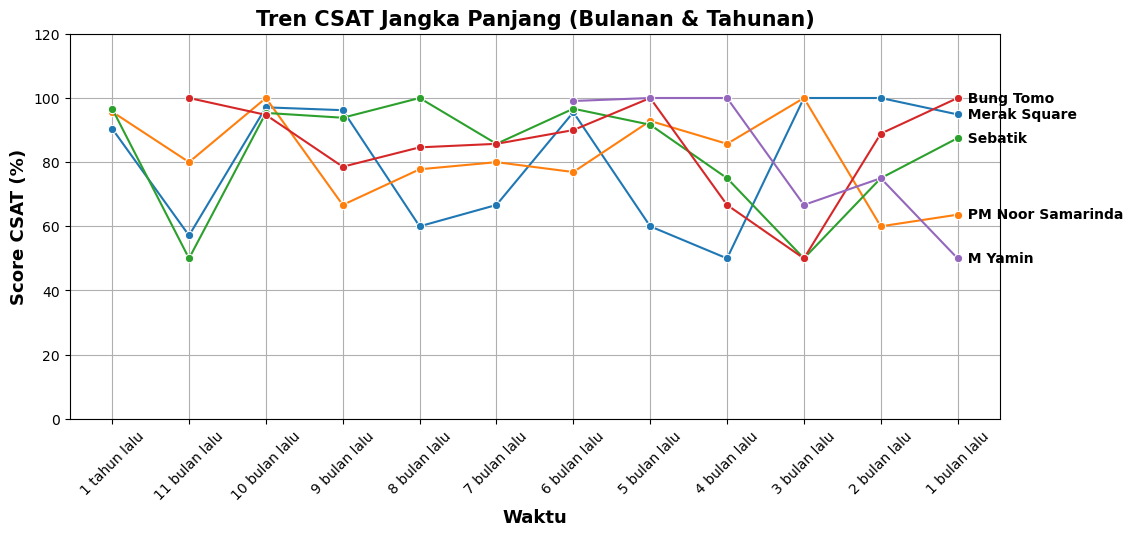

In [17]:
# data viz
#hanya mengambil data yang contain bulan atau tahun
df_makro = df_akhir_csat[
    df_akhir_csat["waktu_relatif"].str.contains("bulan|tahun", na=False)
].copy()

#membuang categori tidak digunakan dari memory untuk plot
df_makro["waktu_relatif"] = df_makro["waktu_relatif"].cat.remove_unused_categories()

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_makro, x="waktu_relatif", y="skor_csat", hue="cafe", marker="o", legend=False
)
plt.title("Tren CSAT Jangka Panjang (Bulanan & Tahunan)", fontsize=15, fontweight='bold')
plt.xlabel("Waktu",fontsize=13, fontweight='bold')
plt.ylabel("Score CSAT (%)",fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.ylim(0, 120)
plt.grid(True)
# 2. Proses menaruh nama di ujung garis
for nama_cafe, group in df_makro.groupby("cafe"):
    titik_terakhir = group.iloc[-1]
    plt.text(
        x=titik_terakhir["waktu_relatif"], 
        y=titik_terakhir["skor_csat"], 
        s=f"  {nama_cafe}", 
        va="center", 
        ha="left", 
        fontsize=10, 
        weight="bold"
    )

plt.savefig(
    'data_viz/Tren_CSAT_Jangka_Panjang.png', 
    dpi=300, 
    bbox_inches='tight'
)


plt.show()

In [18]:
df_akhir_csat.head(3)

,waktu_relatif,skor_csat,cafe,total_review
0,1 tahun lalu,90.429043,Merak Square,303
1,1 tahun lalu,95.714286,PM Noor Samarinda,140
2,1 tahun lalu,96.644295,Sebatik,149


## Smoothing with Moving Average to look up the trend and personalized cafe data

### Bung Tomo

In [77]:

f_tomo = df_makro['cafe'] == 'M Yamin'
PM_Noor = df_makro.loc[f_tomo].copy()

PM_Noor['MA_3'] = PM_Noor['skor_csat'].rolling(window=3, min_periods=1).mean()


PM_Noor

,waktu_relatif,skor_csat,cafe,total_review,MA_3
24,6 bulan lalu,99.065421,M Yamin,107,99.065421
29,5 bulan lalu,100.000000,M Yamin,4,99.532710
34,4 bulan lalu,100.000000,M Yamin,6,99.688474
39,3 bulan lalu,66.666667,M Yamin,6,88.888889
44,2 bulan lalu,75.000000,M Yamin,8,80.555556
49,1 bulan lalu,50.000000,M Yamin,12,63.888889


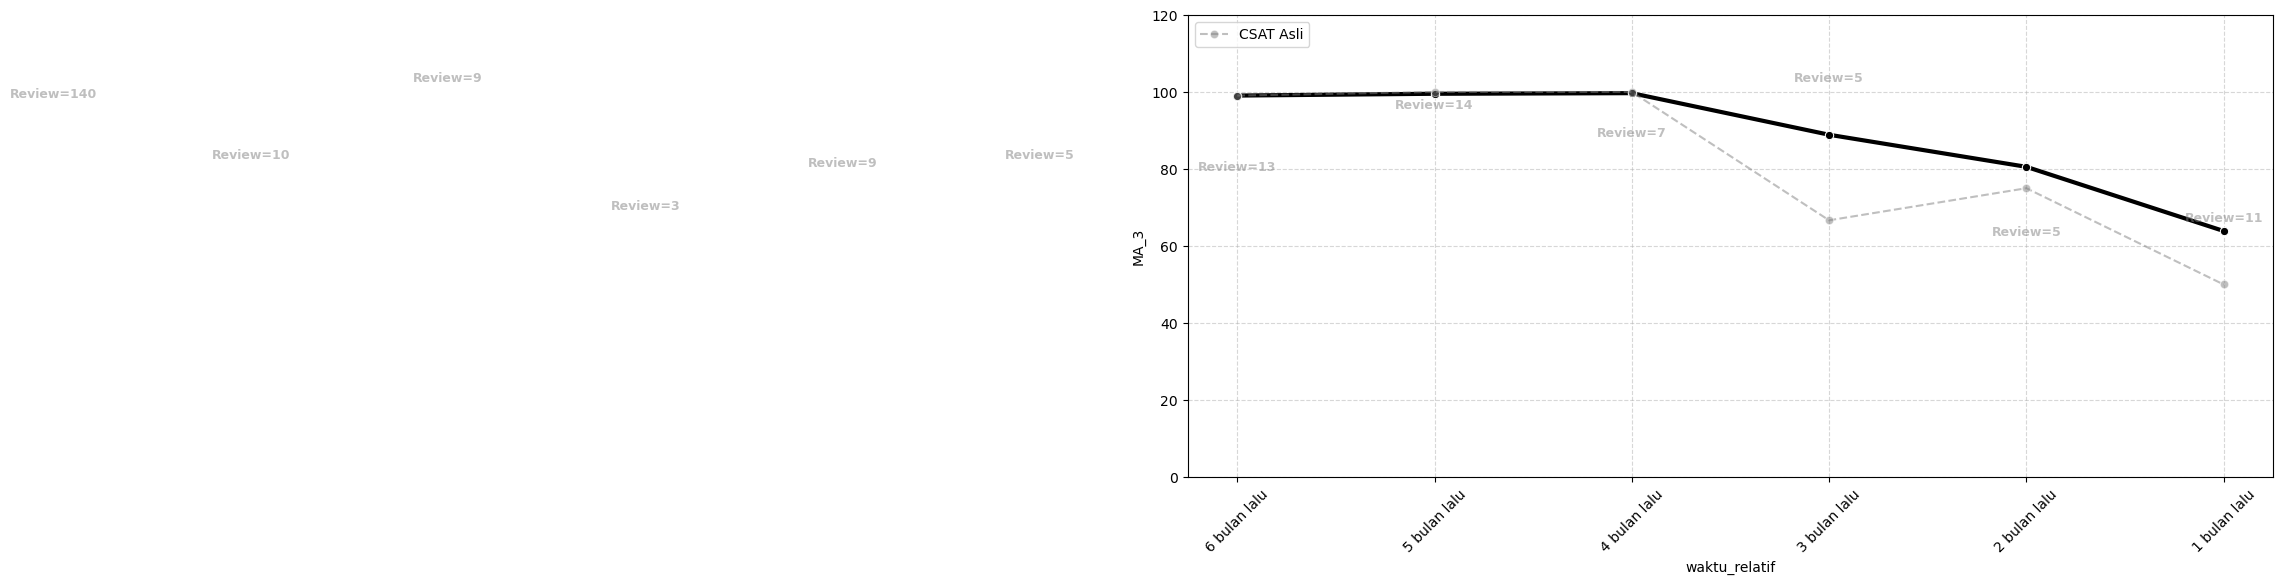

In [79]:
#data viz
plt.figure(figsize=(14, 6))
sns.lineplot(data=PM_Noor, x='waktu_relatif', y='MA_3',marker="o", color='black', linewidth=3)
sns.lineplot(
    data=PM_Noor, x='waktu_relatif', y='skor_csat', 
    marker='o', color='gray', alpha=0.5, linestyle='--', label='CSAT Asli'
)

for index, row in bung_tomo.iterrows():

    if pd.isna(row["skor_csat"]):
        continue
        
    plt.text(
        x=row["waktu_relatif"],            
        y=row["skor_csat"] + 2,             
        s=f"Review={int(row['total_review'])}",  
        ha="center", 
        va="bottom", 
        fontsize=9, 
        color="gray",                       
        weight="semibold",
        alpha=0.5
    )

plt.xticks(rotation=45)
plt.ylim(0, 120)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="upper left")
plt.show()

In [81]:
PM_Noor[1:].skor_csat.mean()

78.33333333333333

In [83]:
PM_Noor

,waktu_relatif,skor_csat,cafe,total_review,MA_3
24,6 bulan lalu,99.065421,M Yamin,107,99.065421
29,5 bulan lalu,100.000000,M Yamin,4,99.532710
34,4 bulan lalu,100.000000,M Yamin,6,99.688474
39,3 bulan lalu,66.666667,M Yamin,6,88.888889
44,2 bulan lalu,75.000000,M Yamin,8,80.555556
49,1 bulan lalu,50.000000,M Yamin,12,63.888889


In [85]:
PM_Noor[1:]

,waktu_relatif,skor_csat,cafe,total_review,MA_3
29,5 bulan lalu,100.000000,M Yamin,4,99.532710
34,4 bulan lalu,100.000000,M Yamin,6,99.688474
39,3 bulan lalu,66.666667,M Yamin,6,88.888889
44,2 bulan lalu,75.000000,M Yamin,8,80.555556
49,1 bulan lalu,50.000000,M Yamin,12,63.888889


### Automatisasi

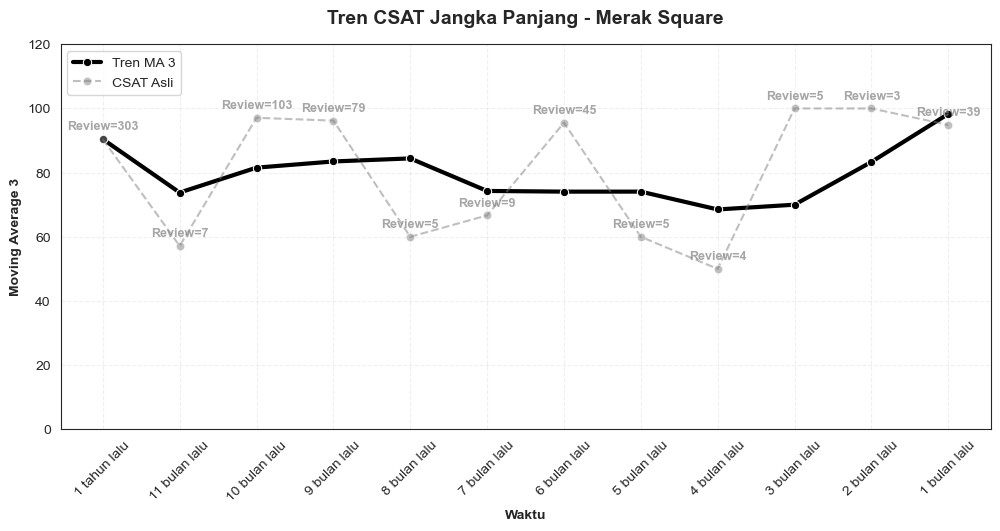

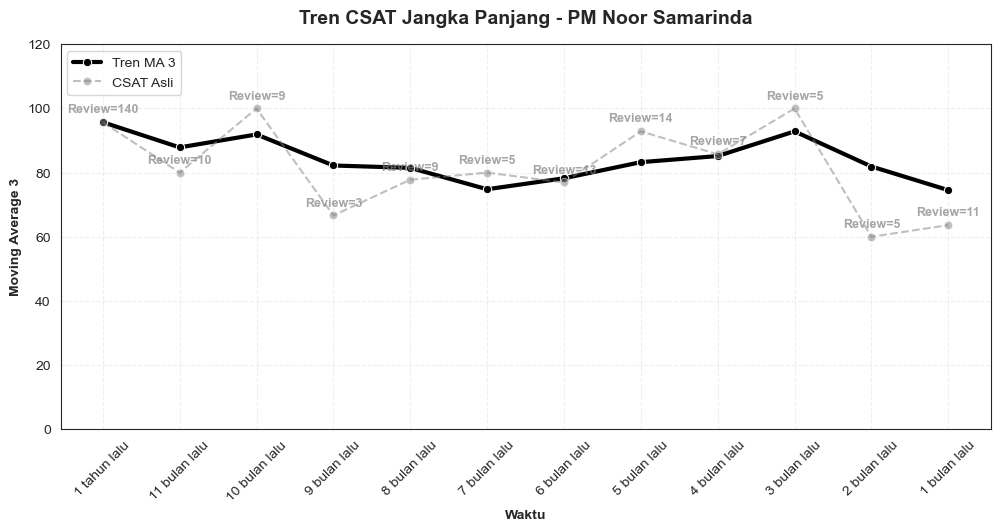

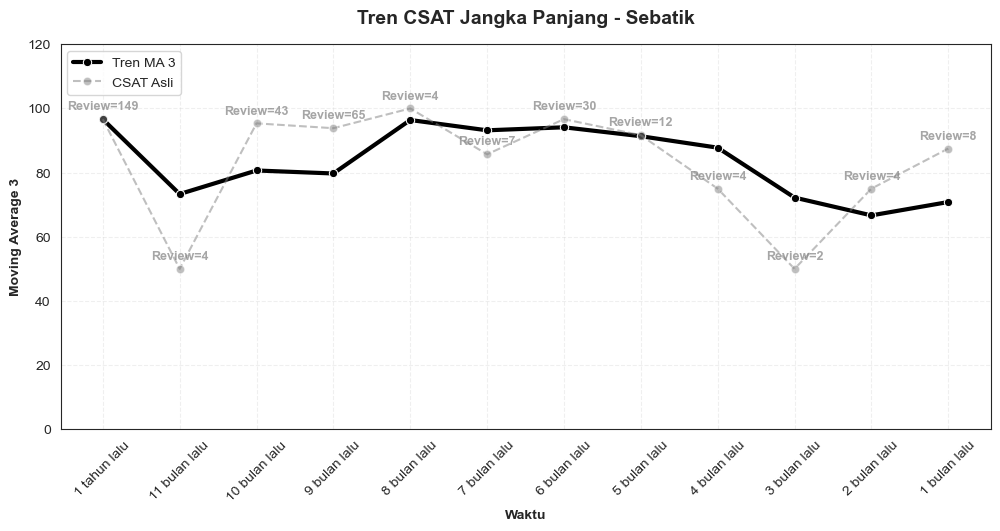

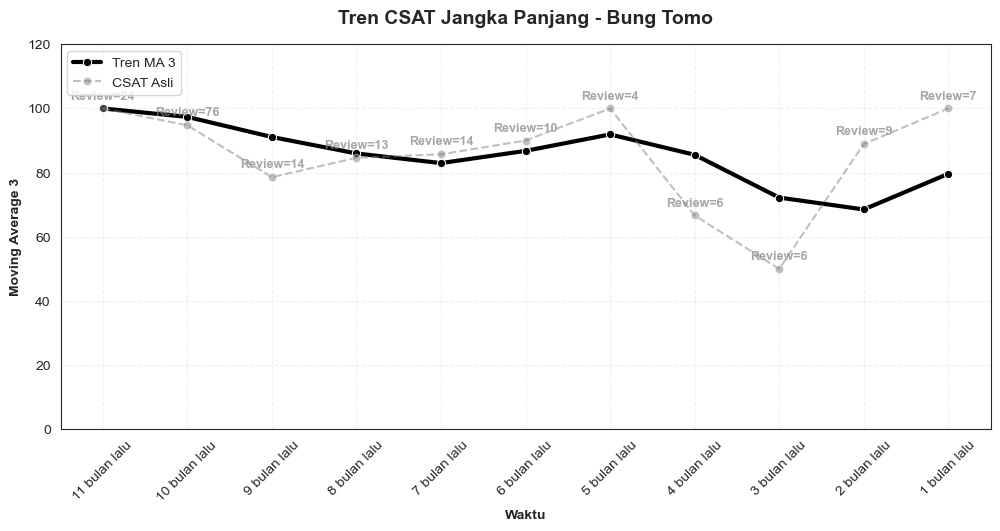

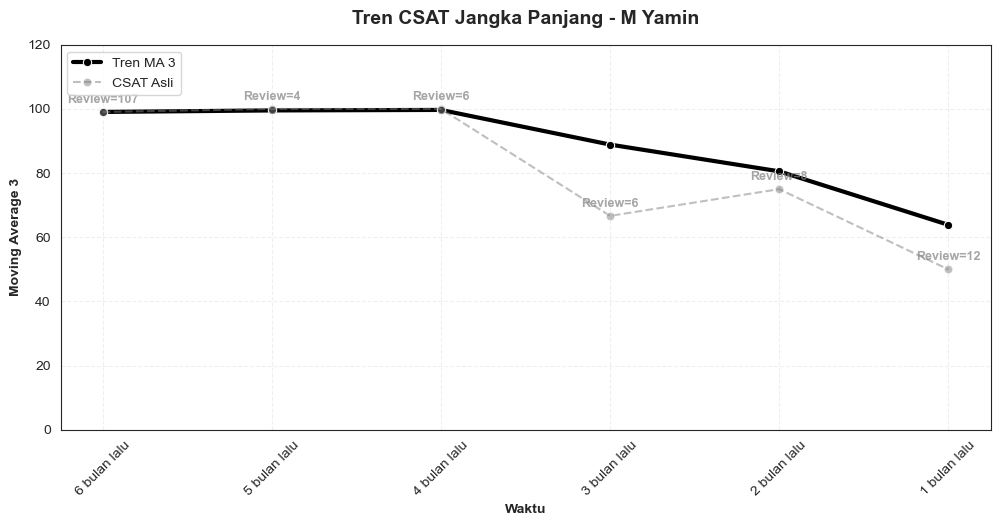

In [276]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('data_viz_trend', exist_ok=True)

df_makro = df_makro.sort_values(by="waktu_relatif").reset_index(drop=True)

for i in list(df_makro.cafe.unique()):

    f_tomo = df_makro['cafe'] == i
    bung_tomo = df_makro.loc[f_tomo].copy()
    

    bung_tomo['MA_3'] = bung_tomo['skor_csat'].rolling(window=3, min_periods=1).mean()
    

    plt.figure(figsize=(12, 5))
    

    sns.lineplot(
        data=bung_tomo, x='waktu_relatif', y='MA_3',
        marker="o", color='black', linewidth=3, label='Tren MA 3'
    )

    sns.lineplot(
        data=bung_tomo, x='waktu_relatif', y='skor_csat', 
        marker='o', color='gray', alpha=0.5, linestyle='--', label='CSAT Asli'
    )
    
    for index, row in bung_tomo.iterrows():
        if pd.isna(row["skor_csat"]):
            continue
            
        plt.text(
            x=row["waktu_relatif"],             
            y=row["skor_csat"] + 2,             
            s=f"Review={int(row['total_review'])}",  
            ha="center", 
            va="bottom", 
            fontsize=9, 
            color="gray",                       
            weight="semibold",
            alpha=0.7                           
        )
    
    plt.title(f"Tren CSAT Jangka Panjang - {i}", fontsize=14, pad=15, fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylim(0, 120)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc="upper left")
    plt.ylabel("Moving Average 3", fontweight='bold')
    plt.xlabel("Waktu", fontweight='bold')
    plt.savefig(
        f'data_viz_trend/Tren_CSAT_Jangka_Panjang_{i}.png', 
        dpi=300, 
        bbox_inches='tight'
    )
    plt.show()
    plt.close() 

# Variabel yang mempengaruhi CSAT: Geografis, Makanan, Layanan, Suasana

In [92]:
df = pd.read_parquet('data_review_full_bersih.parquet')
df.head(3)

,nama_reviewer,rating,waktu_relatif,review,Makanan,Layanan,Suasana,Tarif per orang,Tingkat kebisingan,Waktu tunggu,Jenis pesanan,Jenis makanan,Tempat parkir,Opsi tempat parkir,Ukuran grup,cafe,Tingkat Kepuasan,tanggal_pasti
0,Rizak Mada Astanto,5,2 hari lalu,Terbaiiik,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PM Noor Samarinda,Puas,2026-06-24
1,Diah ADHYAKSANTI,5,1 minggu lalu,"Makanan enak, pelayanan bagus, dan kebisingan ...",<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PM Noor Samarinda,Puas,2026-06-19
2,Sonia Ramadhani,1,1 minggu lalu,"Hapus aja sistem poing member di app, percuma ...",4,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PM Noor Samarinda,Tidak Puas,2026-06-19


## Bung Tomo (reiterasi akan dilakukan dalam cell yang sama)

In [525]:
#filter hanya cafe bung tomo
tomo = df['cafe'] == 'M Yamin'
bung_tomo = df.loc[tomo]

In [527]:
#filter hanya tingka kepuasan, bukan puas
filt_tomo = bung_tomo['Tingkat Kepuasan'] != 'Puas'
bung_tomo = bung_tomo.loc[filt_tomo]

In [529]:
bung_tomo.count()

nama_reviewer         25
rating                25
waktu_relatif         25
review                24
Makanan                8
Layanan               12
Suasana                9
Tarif per orang        8
Tingkat kebisingan     7
Waktu tunggu           0
Jenis pesanan         12
Jenis makanan          3
Tempat parkir          1
Opsi tempat parkir     2
Ukuran grup            1
cafe                  25
Tingkat Kepuasan      25
tanggal_pasti         25
dtype: int64

In [531]:
# rating count
bung_tomo['rating'].value_counts()

rating
1    17
3     5
2     3
Name: count, dtype: int64

In [533]:
# waktu_relatif dengan nrating
bung_tomo[['rating','waktu_relatif']].value_counts().reset_index().sort_values(by='waktu_relatif')

,rating,waktu_relatif,count
1,1,1 bulan lalu,3
2,3,1 bulan lalu,3
3,1,1 minggu lalu,2
11,3,1 minggu lalu,1
5,1,2 bulan lalu,1
12,3,2 bulan lalu,1
0,1,2 minggu lalu,7
8,2,2 minggu lalu,1
6,1,3 bulan lalu,1
9,2,3 bulan lalu,1


In [535]:
# review, most said word
from collections import Counter

teks_utuh = " ".join(bung_tomo['review'].dropna().astype(str)).lower()
teks_bersih = pd.Series(teks_utuh).str.replace(r'[^\w\s]', '', regex=True).values[0]

semua_kata = teks_bersih.split()

hitung_kata = Counter(semua_kata)
df_most_said = pd.DataFrame(hitung_kata.most_common(20), columns=['Kata', 'Frekuensi'])

df_most_said.head(10)

,Kata,Frekuensi
0,saya,26
1,di,24
2,yang,21
3,dan,17
4,ada,14
5,ini,14
6,nya,11
7,ya,9
8,lain,9
9,bisa,9


In [537]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

review_jelek = bung_tomo[bung_tomo['rating'] <= 3]['review'].dropna()

vectorizer = CountVectorizer(ngram_range=(2, 2))
X = vectorizer.fit_transform(review_jelek)

bi_grams = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
frekuensi_bigram = bi_grams.sum().sort_values(ascending=False)

print("--- 10 Pasangan Kata Negatif Terbanyak ---")
print(frekuensi_bigram.head(10))

--- 10 Pasangan Kata Negatif Terbanyak ---
saya perhatikan     3
saya ada            3
tidak nyaman        3
tidak ramah         3
mohon di            3
di tomoro           3
dia langsung        2
gak akan            2
dibanding outlet    2
soal collab         2
dtype: int64


In [539]:
from sklearn.feature_extraction.text import CountVectorizer

review_jelek = bung_tomo[bung_tomo['rating'] <= 3]['review'].dropna()
vectorizer = CountVectorizer(ngram_range=(3, 3))
X = vectorizer.fit_transform(review_jelek)
tri_grams = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
frekuensi_trigram = tri_grams.sum().sort_values(ascending=False)

print("--- 10 Rangkaian 3 Kata Negatif Terbanyak ---")
print(frekuensi_trigram.head(4))

--- 10 Rangkaian 3 Kata Negatif Terbanyak ---
nyaman saya perhatikan    2
tanya soal collab         2
tidak nyaman saya         2
di tomoro cabang          2
dtype: int64


In [541]:
#menyimpan csv berdasarkan given column
csv_bung_tomo = bung_tomo[['nama_reviewer', 'waktu_relatif','review']].copy()
csv_bung_tomo.to_excel('m_yamin.xlsx', index=False)

In [543]:
#load data sudah di fix
hot_bung_tomo = pd.read_excel('m_yamin.xlsx')
hot_bung_tomo.head(3)

,nama_reviewer,waktu_relatif,review,Makanan_rev,Layanan_rev,Suasana_rev,Fasilitas_rev
0,Nadia Pradita,1 minggu lalu,"ihhh sekarang minta rate bintang 5 ke customer ya? REVIEW JUJUR: baristanya terkhusus yang perempuan tidak ramah, collab frieren baristanya kurang diberikan brief yang jelas, wifi gabisa dipake kerja/nugas guyss ke tempat lain aja (saya baca juga dibatasi ya? Minimal koneksinya kenceng lah)\n\nKronologi keresahan saya: ada miskom parah mengenai merch collab sampai hampir gabisa claim PO dan milih (for your information sebulan ini saya udah pindah langganan dan sdh purchase semua merch selalu di tomoro cabang lain dan aman aja lo). Di sini, jadinya ampe sore harus ngelawanin para barita ngotot berwajah masam ini baru bisa claim hak saya. Untung temen saya sabar, pagi saya sekali protes udah kesel banget.\n\nLalu, barista cewek rambut pendek shift malam tgl 28 april 2026 menegur customer dengan gestur yang tidak enak (menunjuk nunjuk dan bertanya berulang), tanpa senyum dan tanpa nada yang ramah. Tolong ini orang disidak deh, liat review lain pengalaman sama bisa jadi orang yang sama, jutek bawaan pabrik nampaknya.\n\nMungkin karena outlet ini masi tergolong baru ya, jadi banyak yang harus dibenahi. Untuk collab event kemarin sepertinya ada problem/miskom internal dan jadi kacau dibanding outlet lain di smd.\nCuman aku harap staffnya bisa lebih ramah lagi (terutama yang shift sore-malem, gatau ini rolling apa engga bagi yang merasa aja). Negur cust juga ga liat-liat dulu barang yang kita bawa itu udah sisa seruput diminum di luar dan tinggal buang sampahnya (PASTI kita buang sendiri kok). Kenapa ada itu minuman, karna kita awalnya ga niat dine in, malam itu cuman mau tanya soal collab. Gausah nunjuk & nanya berkali-kali ""itu minuman apa"" Kalau negur sambil senyum-ketawa gapapa ya, ini gesture, ekspresi, nadanya gaenak ama pake nanya begitu. Orang yang ditegur cuman diem tapi saya merasa ini ga pantes sekali dia digitukan.\n\nSaya nulis ini nahan sebulan lebih karena kasian, namanya kerja pasti ada capeknya dan blunder, tapi setelah liat malah muncul review-review yang mirip ama keluhan saya, yaudah kalian harus tau ini. Kalau kalian baca ini, tolong jangan defensif. Perbaiki aja",0,1,0.0,1
1,Bayu Mahesa,1 minggu lalu,"Jujur ga suka banget sama voucher wifinya tomoro, terlalu membatasin waktunya. Waktunya dibatasin 2 jam pasih jing okee aku kalau 6 jam / 12 jam tapi ini 2 jam dan dibatasi lagi perdivace",0,0,0.0,1
2,Bung Fei,1 minggu lalu,"Biasa, roti kurang enak. Maaf",1,0,0.0,0


In [545]:
#marging df
bung_tomo_final = pd.merge(
    bung_tomo, 
    hot_bung_tomo[['nama_reviewer', 'waktu_relatif', 'Layanan_rev', 'Fasilitas_rev', 'Suasana_rev', 'Makanan_rev']], 
    on=['nama_reviewer', 'waktu_relatif'], 
    how='left'
)

In [547]:
bung_tomo_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   nama_reviewer       25 non-null     object        
 1   rating              25 non-null     int64         
 2   waktu_relatif       25 non-null     object        
 3   review              24 non-null     object        
 4   Makanan             8 non-null      Int64         
 5   Layanan             12 non-null     Int64         
 6   Suasana             9 non-null      Int64         
 7   Tarif per orang     8 non-null      category      
 8   Tingkat kebisingan  7 non-null      category      
 9   Waktu tunggu        0 non-null      category      
 10  Jenis pesanan       12 non-null     category      
 11  Jenis makanan       3 non-null      category      
 12  Tempat parkir       1 non-null      category      
 13  Opsi tempat parkir  2 non-null      category      
 

In [549]:
bung_tomo_final.head()

,nama_reviewer,rating,waktu_relatif,review,Makanan,Layanan,Suasana,Tarif per orang,Tingkat kebisingan,Waktu tunggu,...,Tempat parkir,Opsi tempat parkir,Ukuran grup,cafe,Tingkat Kepuasan,tanggal_pasti,Layanan_rev,Fasilitas_rev,Suasana_rev,Makanan_rev
0,Nadia Pradita,1,1 minggu lalu,"ihhh sekarang minta rate bintang 5 ke customer ya? REVIEW JUJUR: baristanya terkhusus yang perempuan tidak ramah, collab frieren baristanya kurang diberikan brief yang jelas, wifi gabisa dipake kerja/nugas guyss ke tempat lain aja (saya baca juga dibatasi ya? Minimal koneksinya kenceng lah)\n\nKronologi keresahan saya: ada miskom parah mengenai merch collab sampai hampir gabisa claim PO dan milih (for your information sebulan ini saya udah pindah langganan dan sdh purchase semua merch selalu di tomoro cabang lain dan aman aja lo). Di sini, jadinya ampe sore harus ngelawanin para barita ngotot berwajah masam ini baru bisa claim hak saya. Untung temen saya sabar, pagi saya sekali protes udah kesel banget.\n\nLalu, barista cewek rambut pendek shift malam tgl 28 april 2026 menegur customer dengan gestur yang tidak enak (menunjuk nunjuk dan bertanya berulang), tanpa senyum dan tanpa nada yang ramah. Tolong ini orang disidak deh, liat review lain pengalaman sama bisa jadi orang yang sama, jutek bawaan pabrik nampaknya.\n\nMungkin karena outlet ini masi tergolong baru ya, jadi banyak yang harus dibenahi. Untuk collab event kemarin sepertinya ada problem/miskom internal dan jadi kacau dibanding outlet lain di smd.\nCuman aku harap staffnya bisa lebih ramah lagi (terutama yang shift sore-malem, gatau ini rolling apa engga bagi yang merasa aja). Negur cust juga ga liat-liat dulu barang yang kita bawa itu udah sisa seruput diminum di luar dan tinggal buang sampahnya (PASTI kita buang sendiri kok). Kenapa ada itu minuman, karna kita awalnya ga niat dine in, malam itu cuman mau tanya soal collab. Gausah nunjuk & nanya berkali-kali ""itu minuman apa"" Kalau negur sambil senyum-ketawa gapapa ya, ini gesture, ekspresi, nadanya gaenak ama pake nanya begitu. Orang yang ditegur cuman diem tapi saya merasa ini ga pantes sekali dia digitukan.\n\nSaya nulis ini nahan sebulan lebih karena kasian, namanya kerja pasti ada capeknya dan blunder, tapi setelah liat malah muncul review-review yang mirip ama keluhan saya, yaudah kalian harus tau ini. Kalau kalian baca ini, tolong jangan defensif. Perbaiki aja",<NA>,<NA>,<NA>,NaN,NaN,NaN,...,NaN,NaN,NaN,M Yamin,Tidak Puas,2026-06-19,1,1,0.0,0
1,Bayu Mahesa,1,1 minggu lalu,"Jujur ga suka banget sama voucher wifinya tomoro, terlalu membatasin waktunya. Waktunya dibatasin 2 jam pasih jing okee aku kalau 6 jam / 12 jam tapi ini 2 jam dan dibatasi lagi perdivace",<NA>,<NA>,<NA>,NaN,NaN,NaN,...,NaN,NaN,NaN,M Yamin,Tidak Puas,2026-06-19,0,1,0.0,0
2,Bung Fei,3,1 minggu lalu,"Biasa, roti kurang enak. Maaf",<NA>,<NA>,<NA>,NaN,NaN,NaN,...,NaN,NaN,NaN,M Yamin,Netral,2026-06-19,0,0,0.0,1
3,angel,1,2 minggu lalu,minimal wifi nya di baikin,<NA>,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,M Yamin,Tidak Puas,2026-06-12,0,1,0.0,0
4,ERIEN OCTIARA SABILLA,1,2 minggu lalu,"wifinya tiap kesini selalu jelek, semua yg disini terpaksa stay karna udah terlanjur mesen minum makanan bkn karna tempatnya pw, gak akan kesini lagi. cabang tomoro paling jelek di samarinda",<NA>,<NA>,<NA>,NaN,NaN,NaN,...,NaN,NaN,NaN,M Yamin,Tidak Puas,2026-06-12,0,1,1.0,0


In [551]:
#mengubah format data asli menjadi 
aspek_asli = ['Makanan', 'Layanan', 'Suasana']

def to_problem_flag(x):
    if pd.isna(x):
        return pd.NA
    return 1 if x <= 3 else 0

problem_asli = bung_tomo_final[aspek_asli].apply(lambda col: col.map(to_problem_flag))

In [553]:
# layanan, makanan, suasana berdasarkan data asli (akan dihutung 1 jika ada rating 1-3)
problem_asli[['Makanan','Layanan','Suasana']].sum()

Makanan    1
Layanan    9
Suasana    4
dtype: object

In [555]:
#rev dari excel manual
bung_tomo_final[['Layanan_rev','Fasilitas_rev','Suasana_rev','Makanan_rev']].sum()

Layanan_rev      14.0
Fasilitas_rev    13.0
Suasana_rev       2.0
Makanan_rev       2.0
dtype: float64

In [557]:
sum_asli = problem_asli[['Makanan', 'Layanan', 'Suasana']].sum()
sum_rev = bung_tomo_final[['Layanan_rev','Fasilitas_rev','Suasana_rev','Makanan_rev']].sum()

pct_asli = (sum_asli / sum_asli.sum()) * 100
pct_rev = (sum_rev / sum_rev.sum()) * 100

In [559]:
print("ANGKA KETIDAKPUASAN PADA TIAP KATEGORI BERDASARKAN KOLOM MAKANAN, LAYANAN, DAN SUASANA")
pct_asli.sort_values(ascending=False)

ANGKA KETIDAKPUASAN PADA TIAP KATEGORI BERDASARKAN KOLOM MAKANAN, LAYANAN, DAN SUASANA


Layanan    64.285714
Suasana    28.571429
Makanan     7.142857
dtype: object

In [561]:
print("ANGKA KETIDAKPUASAN PADA TIAP KATEGORI BERDASARKAN KOLOM REVIEW")
pct_rev.sort_values(ascending=False)

ANGKA KETIDAKPUASAN PADA TIAP KATEGORI BERDASARKAN KOLOM REVIEW


Layanan_rev      45.161290
Fasilitas_rev    41.935484
Suasana_rev       6.451613
Makanan_rev       6.451613
dtype: float64